# 🔬 Lensless Face Recognition — Google Colab
**Paper:** Privacy-Preserving Face Recognition and Verification With Lensless Camera (IEEE TBIOM 2024)

### ⚡ Before running: Enable GPU
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

## Step 1: Check GPU

In [1]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > GPU')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.64 GB


## Step 2: Clone the Repository

In [2]:
import os
if not os.path.exists('Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'):
    !git clone https://github.com/SatyamSingh-Git/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model.git
else:
    print('Repo already cloned.')
%cd Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model

Repo already cloned.
/content/lensless_face_recognition


## Step 3: Install Dependencies
Colab already has PyTorch with CUDA. We only install the missing extras.

> **Note:** We do NOT pin `numpy` — Colab's default numpy 2.x is fully compatible with this repo.

In [3]:
!pip install -q joblib scikit-learn scipy six tensorboard
import numpy as np, torch
print(f'numpy: {np.__version__}  |  torch: {torch.__version__}')
print('All dependencies ready!')

numpy: 1.26.4  |  torch: 2.10.0+cu128
All dependencies ready!


## Step 4: Mount Google Drive + Set Data Paths

### 📥 How to get the **dataset** into Google Drive:
1. Download the zip (~19 GB) from the link below:
   > https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo
2. Unzip on your PC — you'll get a `lensless_data/` folder
3. Upload the entire `lensless_data/` folder to **Google Drive → MyDrive**
4. Run the cell below

### 🏋️ How to get the **pretrained weights** into Google Drive:
1. Download the weights (~few hundred MB) from:
   > https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQAI5HfkPTPnT4zYokmAKaLCAUGn34FcO1CFXHa0eA3iARw?e=nkmEhg
2. Place the `.pth` file at `MyDrive/lensless_weights/pretrained_weights.pth`
3. **OR** use **Step 4b** to upload it directly from your PC (easier for small files)

In [4]:
from google.colab import drive
import os
drive.mount('/content/drive')

# ✏️ Update these if you used different folder names in Drive
TRAIN_DATA = '/content/drive/MyDrive/lensless_data/train/ymdct_npy'
TEST_DATA  = '/content/drive/MyDrive/lensless_data/test/ymdct_npy'
WEIGHTS    = '/content/drive/MyDrive/lensless_weights/pretrained_weights.pth'

print('Train data exists:', os.path.exists(TRAIN_DATA))
print('Test data exists: ', os.path.exists(TEST_DATA))
print('Weights exist:    ', os.path.exists(WEIGHTS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train data exists: False
Test data exists:  False
Weights exist:     False


## Step 4b: Upload Pretrained Weights Directly (Alternative to Drive)
If the weights file is on your PC but not yet in Google Drive, use this to upload it directly.

> ⚠️ This only lasts for the current Colab session (not saved to Drive). Use Step 4 above for permanent storage.

In [6]:
import os
os.makedirs('weights', exist_ok=True)
!wget -O weights/pretrained_weights.pth \
  "https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQAI5HfkPTPnT4zYokmAKaLCAUGn34FcO1CFXHa0eA3iARw?e=nkmEhg&download=1"


--2026-03-09 16:25:59--  https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQAI5HfkPTPnT4zYokmAKaLCAUGn34FcO1CFXHa0eA3iARw?e=nkmEhg&download=1
Resolving mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)... 52.104.26.41, 2a01:111:f402:f05e::41
Connecting to mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)|52.104.26.41|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/pretrained_weights.pth?ga=1 [following]
--2026-03-09 16:25:59--  https://mailmissouri-my.sharepoint.com/personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/pretrained_weights.pth?ga=1
Reusing existing connection to mailmissouri-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 222164634 (212M) [application/octet-stream]
Saving to: ‘weights/pretrained_weights.pth’

weights/pretrained_ 100%[=

## Step 5A: 🏋️ Train from Scratch
*(Skip if using pretrained weights — training takes ~2–5 min/epoch on T4)*

In [ ]:
!python train.py \
    --train_data $TRAIN_DATA \
    --test_data  $TEST_DATA \
    --batch_size 64 \
    --lr 0.05 \
    --num_epoch 100

## Step 5B: 🧪 Test — Face Recognition (Pretrained Weights)
Make sure you completed **Step 4** or **Step 4b** to have the weights available.

In [7]:
# Copy weights from Drive to local weights/ folder (if using Drive path)
import shutil, os
os.makedirs('weights', exist_ok=True)

local_weights = 'weights/pretrained_weights.pth'
if not os.path.exists(local_weights):
    if os.path.exists(WEIGHTS):
        shutil.copy(WEIGHTS, local_weights)
        print('Weights copied from Drive!')
    else:
        raise FileNotFoundError('Weights not found! Complete Step 4 or Step 4b first.')
else:
    print('Weights already in place.')

Weights already in place.


In [9]:
import os

# Download dataset directly from OneDrive to Colab's storage (no PC needed!)
os.makedirs('/content/lensless_data', exist_ok=True)

!wget -O /content/lensless_data.zip \
  "https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1"


--2026-03-09 16:30:01--  https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1
Resolving mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)... 52.104.26.41, 2a01:111:f402:f05e::41
Connecting to mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)|52.104.26.41|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1 [following]
--2026-03-09 16:30:02--  https://mailmissouri-my.sharepoint.com/personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1
Reusing existing connection to mailmissouri-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 20369645425 (19G) [application/x-zip-compressed]
Saving to: ‘/content/lensless_data.zip’

/content/lensless_d 100%[==========

In [10]:
!unzip -q /content/lensless_data.zip -d /content/
!ls /content/lensless_data/  # verify what was extracted


test  train


In [11]:
import os
TRAIN_DATA = '/content/lensless_data/train/ymdct_npy'
TEST_DATA  = '/content/lensless_data/test/ymdct_npy'
print('Train exists:', os.path.exists(TRAIN_DATA))
print('Test exists: ', os.path.exists(TEST_DATA))


Train exists: True
Test exists:  True


In [12]:
# Face Recognition Test
!python test_face_recognition.py \
    --test_data $TEST_DATA \
    --weights weights/pretrained_weights.pth \
    --batch_size 64

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Processed epoch 1 / 40
Processed epoch 2 /

## Step 5C: 🔍 Test — Face Verification (Pretrained Weights)

In [14]:
!python test_face_verification.py \
    --test_data $TEST_DATA \
    --pairs data/verification_pairs.txt \
    --weights weights/pretrained_weights.pth


Accuracy = 9293/10092 = 0.9208283789139913
AUC = 0.9784


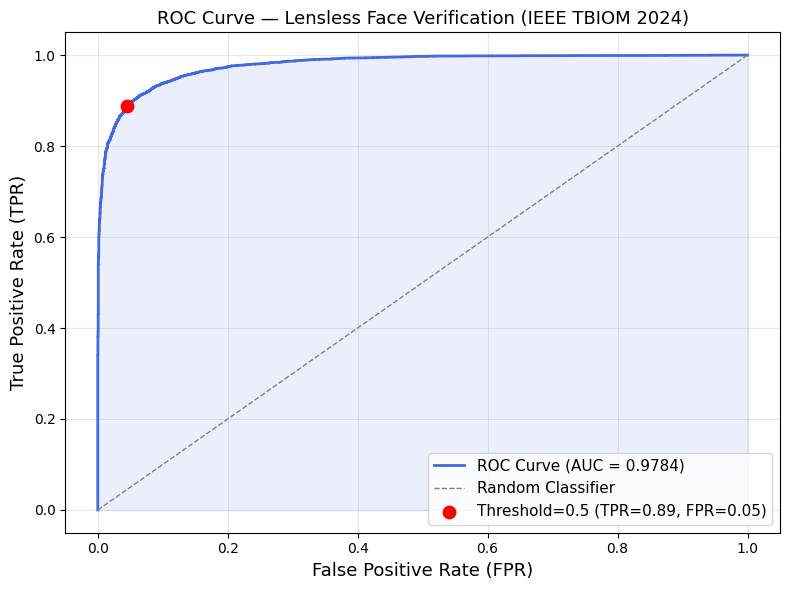

AUC = 0.9784


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

# Load results
with open('results.json', 'r') as f:
    data = json.load(f)

true_labels = data['true_labels']
pred_scores = data['pred_scores']

# Compute ROC curve
fpr, tpr, thresholds = metrics.roc_curve(true_labels, pred_scores)
auc = metrics.roc_auc_score(true_labels, pred_scores)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='royalblue')

# Mark operating point at default threshold (0.5)
default_thresh_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_thresh_idx], tpr[default_thresh_idx],
            color='red', zorder=5, s=80, label=f'Threshold=0.5 (TPR={tpr[default_thresh_idx]:.2f}, FPR={fpr[default_thresh_idx]:.2f})')

plt.xlabel('False Positive Rate (FPR)', fontsize=13)
plt.ylabel('True Positive Rate (TPR)', fontsize=13)
plt.title('ROC Curve — Lensless Face Verification (IEEE TBIOM 2024)', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f'AUC = {auc:.4f}')


## Step 5D: 🤖 Train Transformer (DCT-ViT)
*(Skip if using pretrained weights. Make sure to use GPU.)*

In [ ]:
!python train.py \
    --model transformer \
    --train_data $TRAIN_DATA \
    --test_data  $TEST_DATA \
    --batch_size 32 \
    --lr 1e-4 \
    --num_epoch 100

## Step 5E: 🤖 Test Transformer — Face Recognition


In [ ]:
# Replace logs/best.pth with the actual best checkpoints generated by Step 5D
!python test_face_recognition.py \
    --model transformer \
    --test_data $TEST_DATA \
    --weights logs/best.pth \
    --batch_size 32

## Step 5F: 🤖 Test Transformer — Face Verification

In [ ]:
# Replace logs/best.pth with the actual best checkpoints generated by Step 5D
!python test_face_verification.py \
    --model transformer \
    --test_data $TEST_DATA \
    --pairs data/verification_pairs.txt \
    --weights logs/best.pth


## Step 6: View TensorBoard Logs (Training only)

In [16]:
%load_ext tensorboard
%tensorboard --logdir logs

<IPython.core.display.Javascript object>